In [1]:
import numpy as np
import pandas as pd 
import statistics as sts 
from matplotlib import pyplot as plt 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score,r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor
import joblib
import streamlit as st 
import seaborn as sns

In [2]:
df1=pd.read_csv(r"C:\Shravan\PythonPratice\supervised\Exam_Score_Prediction.csv",encoding_errors='ignore')

In [3]:
df2=df1.copy()

In [4]:
df2.sample(10)

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
13476,13477,18,other,ba,1.03,90.5,yes,8.4,poor,online videos,medium,hard,45.900
14667,14668,22,other,diploma,5.61,94.6,no,6.9,poor,coaching,medium,moderate,87.000
1417,1418,20,female,diploma,3.33,45.5,no,4.9,good,mixed,medium,moderate,54.800
17927,17928,21,male,bca,7.06,98.4,yes,5.9,average,coaching,low,moderate,90.000
485,486,18,male,b.tech,2.48,47.3,yes,4.8,poor,online videos,low,hard,27.200
2418,2419,19,other,bba,7.89,41.1,yes,6.6,good,online videos,low,easy,57.600
12596,12597,23,male,bca,2.27,68.3,yes,6.0,average,self-study,medium,hard,41.800
10294,10295,23,female,ba,3.16,84.7,no,5.4,good,online videos,medium,moderate,69.200
1109,1110,17,other,b.sc,0.51,59.7,yes,5.3,poor,self-study,low,moderate,19.599
7750,7751,22,male,b.com,6.35,94.9,yes,9.0,poor,self-study,high,moderate,79.500


In [5]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


In [6]:
df2.isna().sum()

student_id          0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [7]:
df2.isnull().sum()

student_id          0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [8]:
df2.ndim

2

In [9]:
df2.shape

(20000, 13)

In [10]:
df2.size

260000

In [11]:
df2.columns

Index(['student_id', 'age', 'gender', 'course', 'study_hours',
       'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality',
       'study_method', 'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

In [12]:
df2.drop(columns=['student_id'],axis=0,inplace=True)

In [13]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               20000 non-null  int64  
 1   gender            20000 non-null  object 
 2   course            20000 non-null  object 
 3   study_hours       20000 non-null  float64
 4   class_attendance  20000 non-null  float64
 5   internet_access   20000 non-null  object 
 6   sleep_hours       20000 non-null  float64
 7   sleep_quality     20000 non-null  object 
 8   study_method      20000 non-null  object 
 9   facility_rating   20000 non-null  object 
 10  exam_difficulty   20000 non-null  object 
 11  exam_score        20000 non-null  float64
dtypes: float64(4), int64(1), object(7)
memory usage: 1.8+ MB



 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 1   gender            20000 non-null  object 
 2   course            20000 non-null  object 
 5   internet_access   20000 non-null  object 
 7   sleep_quality     20000 non-null  object 
 8   study_method      20000 non-null  object 
 9   facility_rating   20000 non-null  object 
 10  exam_difficulty   20000 non-null  object 

dtypes: float64(4), int64(1), object(7)
memory usage: 1.8+ MB

In [14]:
df2['exam_difficulty'].value_counts().to_dict()

{'moderate': 9878, 'easy': 6141, 'hard': 3981}

In [15]:
mapping_exam_difficulty={
    'easy':1,
    'moderate':2,
    'hard':3
}
df2['exam_difficulty_encoded']=df2['exam_difficulty'].map(mapping_exam_difficulty)

In [16]:
df2['facility_rating'].value_counts().to_dict()

{'medium': 6760, 'low': 6638, 'high': 6602}

In [17]:
mapping_faculty_rating={
    'low':1,
    'medium':2,
    'high':3
}

df2['facility_rating_encoded']=df2['facility_rating'].map(mapping_faculty_rating)

In [18]:
df2['study_method'].value_counts().to_dict()

{'self-study': 4079,
 'online videos': 4069,
 'coaching': 4036,
 'group study': 3922,
 'mixed': 3894}

In [19]:
mapping_study_method={'self-study': 1,
 'online videos': 2,
 'coaching': 3,
 'group study': 4,
 'mixed': 5}
df2['study_method_encoded']=df2['study_method'].map(mapping_study_method)

In [20]:
df2['sleep_quality'].value_counts().to_dict()

{'average': 6694, 'poor': 6687, 'good': 6619}

In [21]:
mapping_sleep_quality={'average': 1, 'poor': 2, 'good': 3}

df2['sleep_quality_encoded']=df2['sleep_quality'].map(mapping_sleep_quality)

In [22]:
df2['gender'].value_counts().to_dict()

{'other': 6726, 'male': 6695, 'female': 6579}

In [23]:
mapping_gender={'other': 3, 'male': 1, 'female': 2}
df2['gender_encoded']=df2['gender'].map(mapping_gender)


In [24]:
df2['course'].value_counts().to_dict()

{'bca': 2902,
 'ba': 2896,
 'b.sc': 2878,
 'b.com': 2864,
 'bba': 2836,
 'diploma': 2826,
 'b.tech': 2798}

In [25]:
mapping_course={'bca': 1,
 'ba': 2,
 'b.sc': 3,
 'b.com': 4,
 'bba': 5,
 'diploma': 6,
 'b.tech': 7}
df2['course_encoded']=df2['course'].map(mapping_course)

In [26]:
df2['internet_access'].value_counts().to_dict()

{'yes': 16988, 'no': 3012}

In [27]:
mapping_internet_access={'yes': 1, 'no': 2}

df2['internet_access_encoded']=df2['internet_access'].map(mapping_internet_access)

In [28]:
df2.head(10)

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,exam_difficulty_encoded,facility_rating_encoded,study_method_encoded,sleep_quality_encoded,gender_encoded,course_encoded,internet_access_encoded
0,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9,3,1,3,2,1,6,1
1,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8,2,2,2,1,3,1,1
2,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3,2,3,3,2,1,3,1
3,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7,2,1,2,1,3,6,1
4,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7,2,1,3,2,2,6,1
5,23,male,b.tech,3.48,65.4,yes,4.2,good,mixed,low,moderate,58.2,2,1,5,3,1,7,1
6,17,female,b.tech,1.35,69.0,yes,7.4,average,online videos,high,hard,53.7,3,3,2,1,2,7,1
7,22,male,b.sc,5.48,51.1,yes,8.2,poor,self-study,low,moderate,47.3,2,1,1,2,1,3,1
8,18,other,bca,2.89,92.0,yes,6.6,poor,self-study,low,easy,44.9,1,1,1,2,3,1,1
9,17,male,bba,6.77,44.8,yes,9.8,average,group study,high,moderate,77.7,2,3,4,1,1,5,1


In [29]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      20000 non-null  int64  
 1   gender                   20000 non-null  object 
 2   course                   20000 non-null  object 
 3   study_hours              20000 non-null  float64
 4   class_attendance         20000 non-null  float64
 5   internet_access          20000 non-null  object 
 6   sleep_hours              20000 non-null  float64
 7   sleep_quality            20000 non-null  object 
 8   study_method             20000 non-null  object 
 9   facility_rating          20000 non-null  object 
 10  exam_difficulty          20000 non-null  object 
 11  exam_score               20000 non-null  float64
 12  exam_difficulty_encoded  20000 non-null  int64  
 13  facility_rating_encoded  20000 non-null  int64  
 14  study_method_encoded  

In [30]:
df2.select_dtypes(include=['number']).columns

df3=pd.DataFrame(data=df2.select_dtypes(include=['number']))

df3.info()

In [31]:
df3.describe()

,age,study_hours,class_attendance,sleep_hours,exam_score,exam_difficulty_encoded,facility_rating_encoded,study_method_encoded,sleep_quality_encoded,gender_encoded,course_encoded,internet_access_encoded
count,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,20.473300,4.007604,70.017365,7.00856,62.513225,1.892000,1.998200,2.974150,1.996250,2.001550,3.975300,1.150600
std,2.284458,2.308313,17.282262,1.73209,18.908491,0.703179,0.813652,1.411942,0.815886,0.819195,1.998672,0.357667
min,17.000000,0.080000,40.600000,4.10000,19.599000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,18.000000,2.000000,55.100000,5.50000,48.800000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000
50%,20.000000,4.040000,69.900000,7.00000,62.600000,2.000000,2.000000,3.000000,2.000000,2.000000,4.000000,1.000000
75%,22.000000,6.000000,85.000000,8.50000,76.300000,2.000000,3.000000,4.000000,3.000000,3.000000,6.000000,1.000000
max,24.000000,7.910000,99.400000,9.90000,100.000000,3.000000,3.000000,5.000000,3.000000,3.000000,7.000000,2.000000


In [32]:
df3.columns.to_list

<bound method IndexOpsMixin.tolist of Index(['age', 'study_hours', 'class_attendance', 'sleep_hours', 'exam_score',
       'exam_difficulty_encoded', 'facility_rating_encoded',
       'study_method_encoded', 'sleep_quality_encoded', 'gender_encoded',
       'course_encoded', 'internet_access_encoded'],
      dtype='object')>

In [33]:
df3.corr(method='spearman').round(2)

,age,study_hours,class_attendance,sleep_hours,exam_score,exam_difficulty_encoded,facility_rating_encoded,study_method_encoded,sleep_quality_encoded,gender_encoded,course_encoded,internet_access_encoded
age,1.00,0.00,0.01,-0.00,0.00,0.01,0.01,0.01,-0.00,0.00,0.00,0.01
study_hours,0.00,1.00,-0.00,-0.00,0.72,0.01,-0.01,0.01,0.00,-0.00,0.00,0.01
class_attendance,0.01,-0.00,1.00,0.01,0.30,-0.01,0.00,0.01,-0.00,0.00,0.00,-0.01
sleep_hours,-0.00,-0.00,0.01,1.00,0.13,-0.01,-0.01,0.00,0.00,0.01,0.00,0.01
exam_score,0.00,0.72,0.30,0.13,1.00,0.00,0.16,0.09,0.10,0.00,0.00,0.01
exam_difficulty_encoded,0.01,0.01,-0.01,-0.01,0.00,1.00,-0.00,0.01,-0.00,0.01,0.01,0.00
facility_rating_encoded,0.01,-0.01,0.00,-0.01,0.16,-0.00,1.00,0.00,0.00,-0.00,0.01,0.00
study_method_encoded,0.01,0.01,0.01,0.00,0.09,0.01,0.00,1.00,-0.00,0.01,-0.00,0.01
sleep_quality_encoded,-0.00,0.00,-0.00,0.00,0.10,-0.00,0.00,-0.00,1.00,0.00,-0.01,-0.00
gender_encoded,0.00,-0.00,0.00,0.01,0.00,0.01,-0.00,0.01,0.00,1.00,0.00,0.01


In [34]:
pearson=df3.corr(method='pearson').round(2)

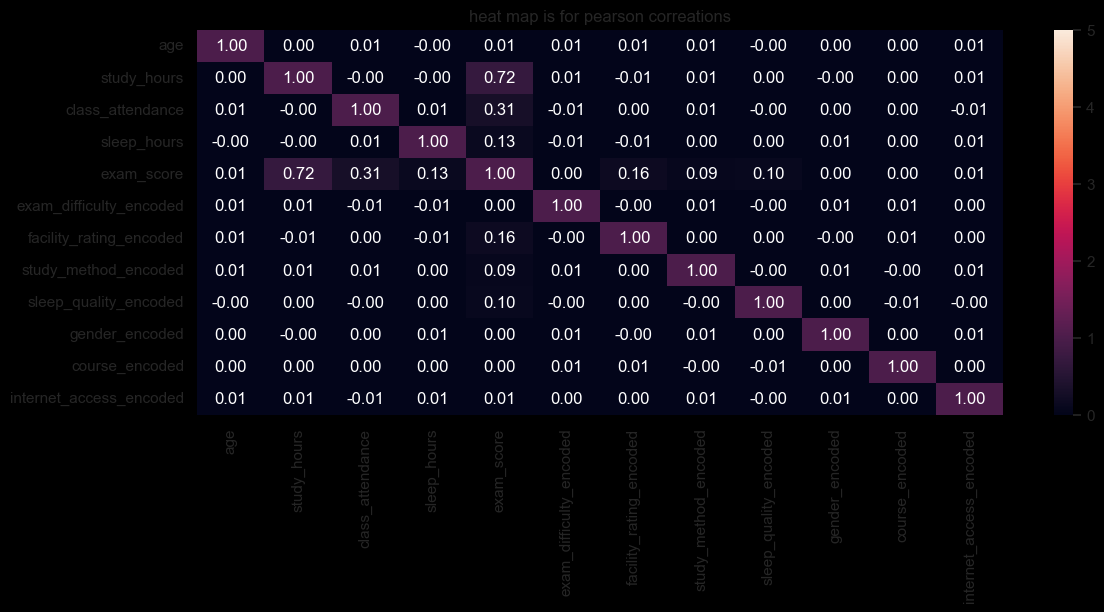

In [35]:
col1=['#ff4d01','#ffffff']

plt.figure(figsize=(13,5))
sns.set_theme(style='white',palette=col1)
sns.heatmap(pearson,fmt=".2f",cbar=True,annot=True,vmin=0,vmax=5)
plt.title('heat map is for pearson correations')
plt.show()

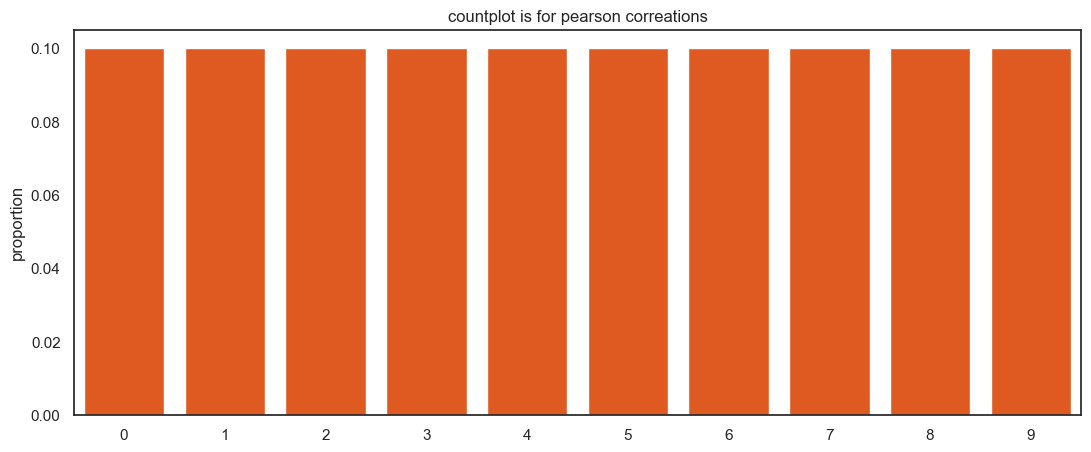

In [36]:
col1=['#ff4d01','#ffffff']

plt.figure(figsize=(13,5))
sns.set_theme(style='white',palette=col1)
sns.countplot(df3['age'].head(10),stat='proportion')
plt.title('countplot is for pearson correations')
plt.show()

<Figure size 1300x500 with 0 Axes>

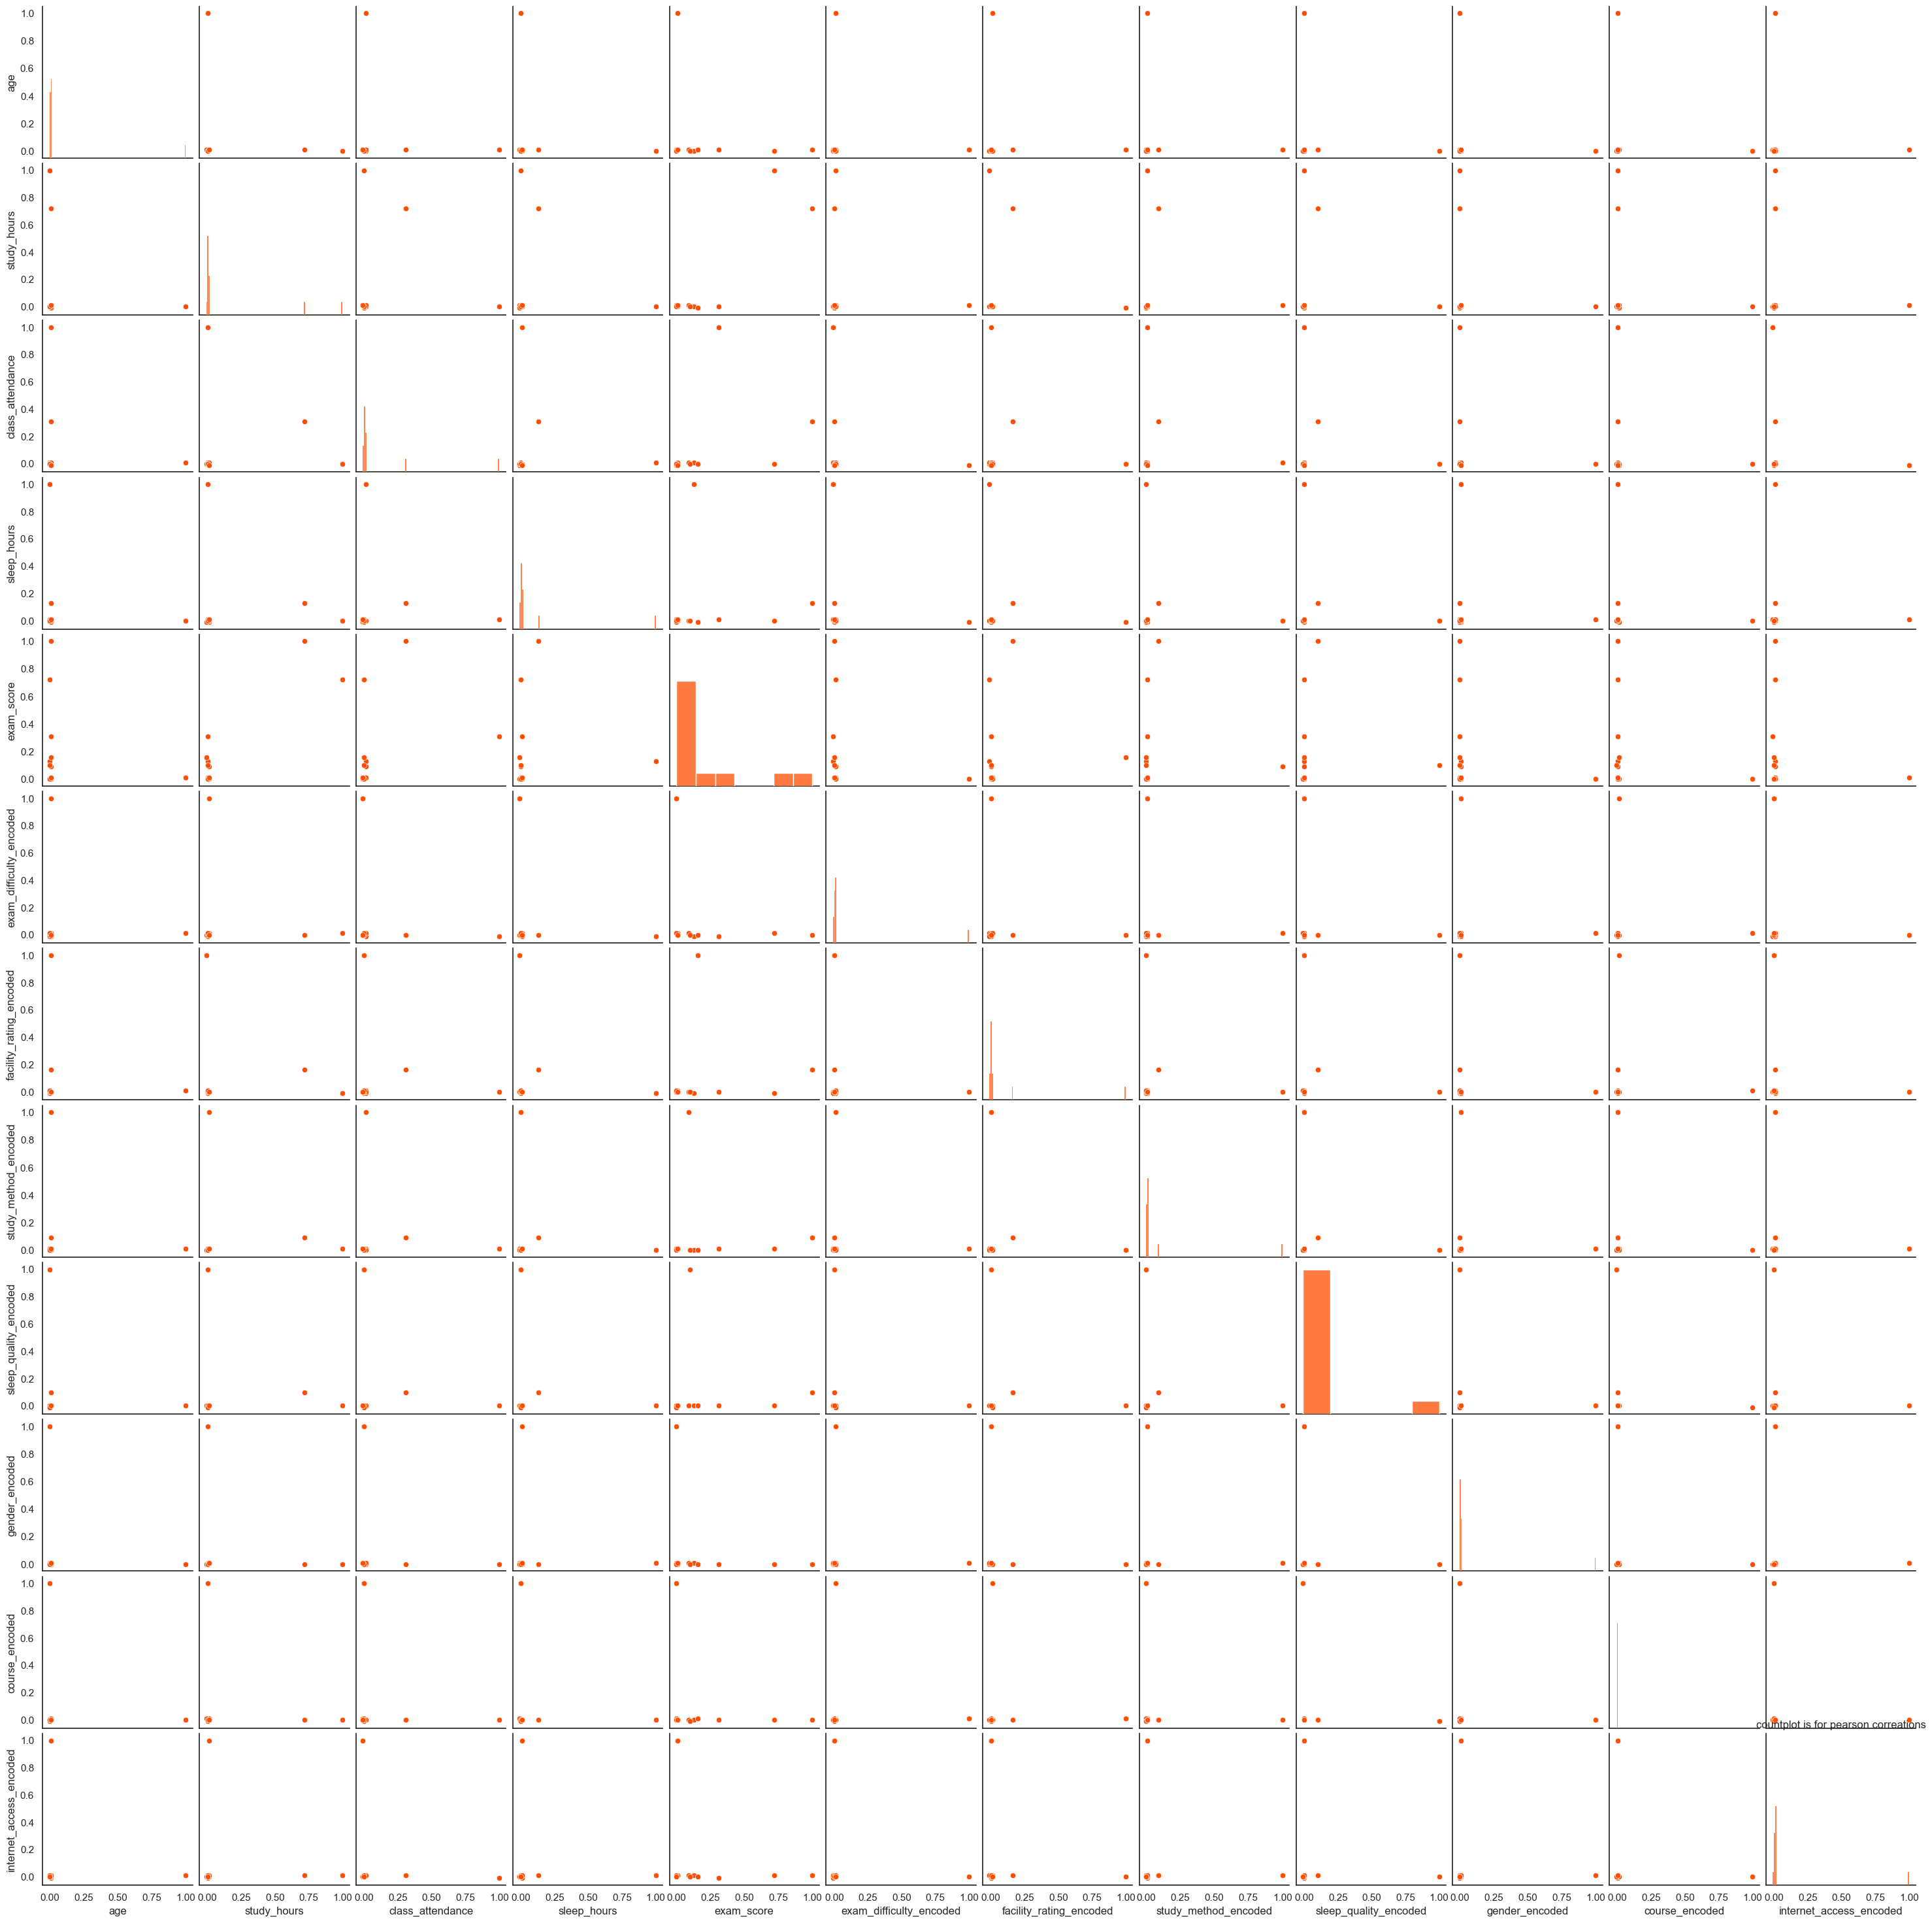

In [37]:
col1=['#ff4d01','#ffffff']

plt.figure(figsize=(13,5))
sns.set_theme(style='white',palette=col1)
sns.pairplot(pearson)
plt.title('countplot is for pearson correations')
plt.show()

In [38]:
df3.columns

Index(['age', 'study_hours', 'class_attendance', 'sleep_hours', 'exam_score',
       'exam_difficulty_encoded', 'facility_rating_encoded',
       'study_method_encoded', 'sleep_quality_encoded', 'gender_encoded',
       'course_encoded', 'internet_access_encoded'],
      dtype='object')

In [39]:
class Anomolies_detection:
    def __init__(self,data):
        self.data=data
        pass
    def anomolies_function(self,column):
        
        mean_value=sts.mean(self.data[column])
        std_dev=sts.stdev(self.data[column])
        cuttoff=3*std_dev
        lower_bound=mean_value-cuttoff
        upper_bound=mean_value+cuttoff
        anomolies=(self.data[column]<lower_bound) | (self.data[column]>upper_bound)
        return anomolies
    
columns_numeric=df3.select_dtypes(include=['number'])

anomolies_instance=Anomolies_detection(df3)

for each_column in columns_numeric.columns:
    results=anomolies_instance.anomolies_function(each_column)
    if results.any():
        print(f"{each_column} and {results}")
    else:
        print(f"{each_column} ->> no anomolies")   

age ->> no anomolies
study_hours ->> no anomolies
class_attendance ->> no anomolies
sleep_hours ->> no anomolies
exam_score ->> no anomolies
exam_difficulty_encoded ->> no anomolies
facility_rating_encoded ->> no anomolies
study_method_encoded ->> no anomolies
sleep_quality_encoded ->> no anomolies
gender_encoded ->> no anomolies
course_encoded ->> no anomolies
internet_access_encoded ->> no anomolies


In [40]:
df3.columns

Index(['age', 'study_hours', 'class_attendance', 'sleep_hours', 'exam_score',
       'exam_difficulty_encoded', 'facility_rating_encoded',
       'study_method_encoded', 'sleep_quality_encoded', 'gender_encoded',
       'course_encoded', 'internet_access_encoded'],
      dtype='object')

In [41]:
x=df3.drop(columns=['exam_score'])
y=df3['exam_score']
y

0        58.9
1        54.8
2        90.3
3        29.7
4        43.7
         ... 
19995    86.5
19996    60.9
19997    64.5
19998    79.0
19999    71.0
Name: exam_score, Length: 20000, dtype: float64

In [42]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [43]:
linear_reg=LinearRegression()

In [44]:
decesion_tree_regressor=DecisionTreeRegressor(max_depth=4,min_samples_split=10,min_samples_leaf=10,splitter='best')

In [45]:
model_pipe1=Pipeline(steps=[
    ("linear_reg",linear_reg)
])
model_pipe2=Pipeline(steps=[
    ("decsion_regressor",decesion_tree_regressor)
])

model_dict={
    "linear_regression":model_pipe1,
    "decsion_regression":model_pipe2
}

for name,model in model_dict.items():
    print(name)
    model.fit(x_train,y_train)
    y_pred_score=model.predict(x_test)
    print(f"pred score : {y_pred_score}")
    print(mean_absolute_error(y_test,y_pred_score))
    print(f"score is : {r2_score(y_test,y_pred_score)}")
    print(root_mean_squared_error(y_test,y_pred_score))
    print(model.score(x_test,y_pred_score))

linear_regression
pred score : [42.40410486 71.66896088 53.27277804 ... 60.89617424 63.0471266
 51.67204581]
8.754791264936838
score is : 0.6728927005456418
10.816899071465304
1.0
decsion_regression
pred score : [38.16887257 71.12600619 68.56038186 ... 61.1005597  71.44555639
 44.56228005]
9.911866881792117
score is : 0.581549007354579
12.234323527414825
1.0


In [ ]:
import matplotlib.pyplot as  plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Plot 1: Train data
plt.subplot(1, 2, 1)
x_train=x_train.squeeze()
sns.scatterplot(x=x_train, y=y_train, label='train-data', color='#ff4d01')
plt.title('Train Data')

# Plot 2: Test data
plt.subplot(1, 2, 2)
sns.scatterplot(x=x_test, y=y_test, label='test-data', color='#ffffff', edgecolor='black')
plt.title('Test Data')

plt.tight_layout()
plt.show()

In [ ]:
#linearcrossscore
cross_score=cross_val_score(linear_reg,x,y,scoring='r2',cv=10)
print(cross_score)
cross_validated_mean=np.mean(cross_score)
print(abs(cross_validated_mean))


In [ ]:
#linearcrossscore
cross_score1=cross_val_score(decesion_tree_regressor,x,y,scoring='r2',cv=10)
print(cross_score1)
cross_validated_mean1=np.mean(cross_score1)
print(abs(cross_validated_mean1))


In [ ]:
# #gridsearchcross score
# param_grids={"criterion":['absolute_error',"squared_error"],"max_depth":[2,4,6,8],"min_samples_split":[5,10,15,20]}
# grid_cv=GridSearchCV(decesion_tree_regressor,param_grid=param_grids,n_jobs=-1,scoring='r2',cv=10)
# grid_cv
# grid_cv.fit(x_train,y_train)


In [ ]:
import joblib

joblib.dump(linear_reg,"linear_reg.joblib")

In [47]:
joblib.dump(decesion_tree_regressor,"decesion_reg.joblib")

['decesion_reg.joblib']

In [49]:
x.columns

Index(['age', 'study_hours', 'class_attendance', 'sleep_hours',
       'exam_difficulty_encoded', 'facility_rating_encoded',
       'study_method_encoded', 'sleep_quality_encoded', 'gender_encoded',
       'course_encoded', 'internet_access_encoded'],
      dtype='object')

In [53]:
df3.describe()

,age,study_hours,class_attendance,sleep_hours,exam_score,exam_difficulty_encoded,facility_rating_encoded,study_method_encoded,sleep_quality_encoded,gender_encoded,course_encoded,internet_access_encoded
count,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,20.473300,4.007604,70.017365,7.00856,62.513225,1.892000,1.998200,2.974150,1.996250,2.001550,3.975300,1.150600
std,2.284458,2.308313,17.282262,1.73209,18.908491,0.703179,0.813652,1.411942,0.815886,0.819195,1.998672,0.357667
min,17.000000,0.080000,40.600000,4.10000,19.599000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,18.000000,2.000000,55.100000,5.50000,48.800000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000
50%,20.000000,4.040000,69.900000,7.00000,62.600000,2.000000,2.000000,3.000000,2.000000,2.000000,4.000000,1.000000
75%,22.000000,6.000000,85.000000,8.50000,76.300000,2.000000,3.000000,4.000000,3.000000,3.000000,6.000000,1.000000
max,24.000000,7.910000,99.400000,9.90000,100.000000,3.000000,3.000000,5.000000,3.000000,3.000000,7.000000,2.000000


In [ ]:
import joblib
import pandas as pd
import streamlit as st
import time


try:
    model1 = joblib.load("decesion_reg.joblib")
    model2 = joblib.load("linear_reg.joblib")
    st.balloons()
    st.header(
        "Decesion tree regression + Linear Regression Model is loaded successfully ....."
    )
    st.title("Exam Score predication ")
    with st.form(key="form-inputs"):
        with st.sidebar:
            st.header("Choose the input parameters ranges")
            age = st.number_input("age", min_value=17, max_value=30, value=30)
            study_hours = st.number_input(
                "study_hours", min_value=1, max_value=10, value=8
            )
            class_attendance = st.number_input(
                "class_attendance", min_value=30, max_value=90, value=30
            )
            sleep_hours = st.number_input(
                "sleep_hours", min_value=0, max_value=10, value=8
            )
            exam_difficulty_encoded = st.number_input(
                "exam_difficulty_encoded", min_value=0, max_value=3, value=2
            )
            facility_rating_encoded = st.number_input(
                "facility_rating_encoded", min_value=0, max_value=3, value=1
            )
            study_method_encoded = st.number_input(
                "study_method_encoded", min_value=0, max_value=6, value=2
            )
            sleep_quality_encoded = st.number_input(
                "sleep_quality_encoded", min_value=0, max_value=4, value=2
            )
            gender_encoded = st.number_input(
                "gender_encoded", min_value=0, max_value=3, value=2
            )
            course_encoded = st.number_input(
                "course_encoded", min_value=0, max_value=7, value=2
            )
            internet_access_encoded = st.number_input(
                "internet_access_encoded", min_value=1, max_value=2, value=1
            )
            submit_buttom = st.form_submit_button(label="submit")

            if submit_buttom:
                st.spinner("form is submitting", show_time=True)
                time.sleep(2)
                st.success("form is submitted")
                st.balloons()
            else:
                st.warning("form is not submitted")
    data_dict = {
        "age": age,
        "study_hours": study_hours,
        "class_attendance": class_attendance,
        "sleep_hours": sleep_hours,
        "exam_difficulty_encoded": exam_difficulty_encoded,
        "facility_rating_encoded": facility_rating_encoded,
        "study_method_encoded": study_method_encoded,
        "sleep_quality_encoded": sleep_quality_encoded,
        "gender_encoded": gender_encoded,
        "course_encoded": course_encoded,
        "internet_access_encoded": internet_access_encoded,
    }

    df1 = pd.DataFrame(data=data_dict, index=[0])
    prediations1 = model1.predict(df1)
    st.code("this the decisiontree regressor")
    st.code(f"The Exam score is {abs(prediations1[0]):,.2f}")
    st.code("this the linear regressor")
    prediations2=model2.predict(df1)
    st.code(f"The Exam score is {abs(prediations2[0]):,.2f}")
    st.write("Thank you ....!")

    st.header("bar chart")
    st.bar_chart(df1)

    st.header("line chart")
    st.line_chart(df1)

    st.code("showing the interms of table format")
    st.table(df1)
    st.data_editor(df1)

except Exception as e:
    st.error(f"{str(e)}")
    st.code(str(e), language="python")

else:
    st.success("no errors in the code")
finally:
    st.success("no errors in the code and final balock is executed")


2026-01-01 12:19:01.778 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-01 12:19:01.779 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-01 12:19:01.780 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-01 12:19:01.782 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-01 12:19:01.783 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-01 12:19:01.784 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-01 12:19:01.784 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-01 12:19:01.785 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar